# 02_texto_baseline — Sentimiento en tweets (BetSentiment ES)
Este notebook entrena un **baseline** (TF‑IDF + Logistic Regression) y guarda el modelo en `../models/`.

**Dataset:** `../data/text/tweets_sentiment.csv` (tu archivo adjunto)


In [1]:
!pip install pandas numpy matplotlib scikit-learn joblib


  Using cached matplotlib-3.10.8-cp311-cp311-win_amd64.whl.metadata (52 kB)
Using cached matplotlib-3.10.8-cp311-cp311-win_amd64.whl (8.1 MB)


In [2]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

## 1) Cargar CSV
Tu CSV **no está en UTF‑8**, así que lo cargamos con `latin-1`.


In [3]:
PATH = "../data/text/tweets_sentiment.csv"

df = pd.read_csv(PATH, sep=",", encoding="latin-1", engine="python")
print("Filas:", len(df))
print("Columnas:", df.columns.tolist())
df.head(3)

Filas: 132707
Columnas: ['tweet_date_created', 'tweet_id', 'tweet_text', 'language', 'sentiment', 'sentiment_score']


,tweet_date_created,tweet_id,tweet_text,language,sentiment,sentiment_score
0,2018-08-08T13:09:15.489000,1027179935184703489,"Alisson puede estar más tranquilo, no cargará ...",es,POSITIVE,"{""Neutral"":0.082259356975555419921875,""Negativ..."
1,2018-08-08T18:27:37.320000,1027260056092344320,@iPincheViky @ChelseaFC Es que el director eje...,es,NEUTRAL,"{""Neutral"":0.827011644840240478515625,""Negativ..."
2,2018-08-12T14:59:31.520000,1028657238116843520,Upto £100 #freebets &gt; https://t.co/cbjeMXI9...,es,NEUTRAL,"{""Neutral"":0.930982112884521484375,""Negative"":..."


## 2) Revisar etiquetas y balanceo
Verás que está muy desbalanceado (mucho NEUTRAL). Lo mitigaremos con `class_weight='balanced'`.


In [4]:
df["sentiment"].value_counts()

sentiment
NEUTRAL     111334
POSITIVE     11004
NEGATIVE      9489
MIXED          880
Name: count, dtype: int64

## 3) Limpieza ligera de texto
Quitamos URLs, menciones, saltos de línea, y normalizamos espacios.
No hacemos una limpieza agresiva para no destruir información útil.


In [5]:
def clean_tweet(text: str) -> str:
    if not isinstance(text, str):
        return ""
    t = text
    # HTML entities comunes (en este dataset aparecen &gt; etc.)
    t = t.replace("&gt;", " ").replace("&lt;", " ").replace("&amp;", " ")
    # URLs
    t = re.sub(r"http\S+|www\S+", " ", t)
    # menciones @usuario
    t = re.sub(r"@\w+", " ", t)
    # hashtags -> quitamos el # pero dejamos la palabra
    t = re.sub(r"#(\w+)", r"\1", t)
    # caracteres raros de control
    t = t.replace("\n", " ").replace("\r", " ").replace("\t", " ")
    # espacios múltiples
    t = re.sub(r"\s+", " ", t).strip()
    return t

df["texto"] = df["tweet_text"].astype(str).map(clean_tweet)

# Mapeo de etiquetas a 3 clases (NEG/NEU/POS)
mapa = {"NEGATIVE":"NEG", "NEUTRAL":"NEU", "POSITIVE":"POS", "MIXED":"NEU"}  # MIXED lo pasamos a NEU
df["label"] = df["sentiment"].map(mapa)

df = df[["texto", "label"]].dropna()
df["label"].value_counts()

label
NEU    112214
POS     11004
NEG      9489
Name: count, dtype: int64

## 4) Split train/test (estratificado)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    df["texto"], df["label"],
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

len(X_train), len(X_test)

(106165, 26542)

## 5) Entrenar baseline (TF‑IDF + Logistic Regression)
- Usamos `ngram_range=(1,2)` para capturar bigramas.
- Usamos `class_weight='balanced'` por el desbalanceo.


In [7]:
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        ngram_range=(1, 2),
        max_features=50000,
        min_df=2
    )),
    ("clf", LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        n_jobs=None
    ))
])

pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


## 6) Evaluación (report + matriz de confusión)


              precision    recall  f1-score   support

         NEG     0.4420    0.7929    0.5676      1898
         NEU     0.9686    0.8477    0.9041     22443
         POS     0.4897    0.7778    0.6010      2201

    accuracy                         0.8380     26542
   macro avg     0.6334    0.8062    0.6909     26542
weighted avg     0.8913    0.8380    0.8549     26542



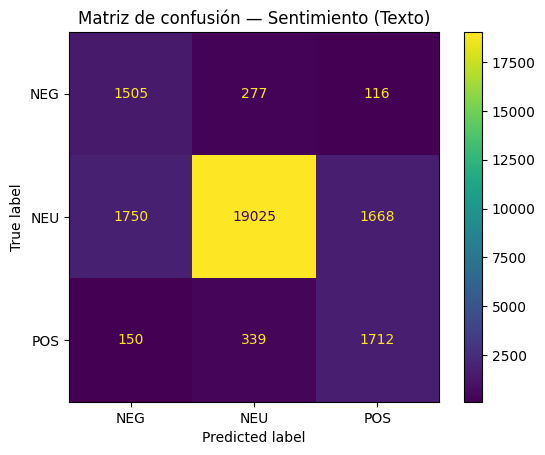

In [8]:
y_pred = pipeline.predict(X_test)
print(classification_report(y_test, y_pred, digits=4))

labels = ["NEG", "NEU", "POS"]
cm = confusion_matrix(y_test, y_pred, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(values_format="d")
plt.title("Matriz de confusión — Sentimiento (Texto)")
plt.show()

## 7) Guardar modelo
Guardamos el pipeline completo (TF‑IDF + clasificador) en `../models/`.


In [9]:
OUT_MODEL = "../models/text_model_tfidf_lr_v1.pkl"
joblib.dump(pipeline, OUT_MODEL)
print("Guardado:", OUT_MODEL)

Guardado: ../models/text_model_tfidf_lr_v1.pkl


## 8) (Opcional) Guardar dataset limpio para Transformers
Esto te deja un CSV pequeño y limpio para el fine‑tuning en tu RTX.


In [10]:
OUT_CLEAN = "../data/text/tweets_sentiment_clean.csv"
df.to_csv(OUT_CLEAN, index=False, encoding="utf-8")
print("Guardado:", OUT_CLEAN)
df.head(3)

Guardado: ../data/text/tweets_sentiment_clean.csv


,texto,label
0,"Alisson puede estar más tranquilo, no cargará ...",POS
1,Es que el director ejecutivo es mujer. So... J...,NEU
2,Upto £100 freebets lol gunners matchedbetting ...,NEU
